# 05 — Model comparison (number of endmembers)

Compare p = 2…7 archetypes using the precomputed multi-trial sweep
(`python scripts/run_sweep.py`): RMSE and archetype stability vs p,
the archetype **lineage** (which archetype splits as p grows), and
per-p loadings with error bars over trials.

All plots load `data/processed/sweep/p{p}/` — nothing is recomputed here.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config
from src.data.loading import load_sweep
from src.unmixing.matching import archetype_lineage

sns.set_style('whitegrid')
config = load_config()

sweep = load_sweep(config)
ps = sorted(sweep)
n_trials = sweep[ps[0]]['meta']['n_trials']
print(f'p values: {ps}, {n_trials} trials each')

p values: [2, 3, 4, 5, 6, 7], 50 trials each


## RMSE and stability vs p

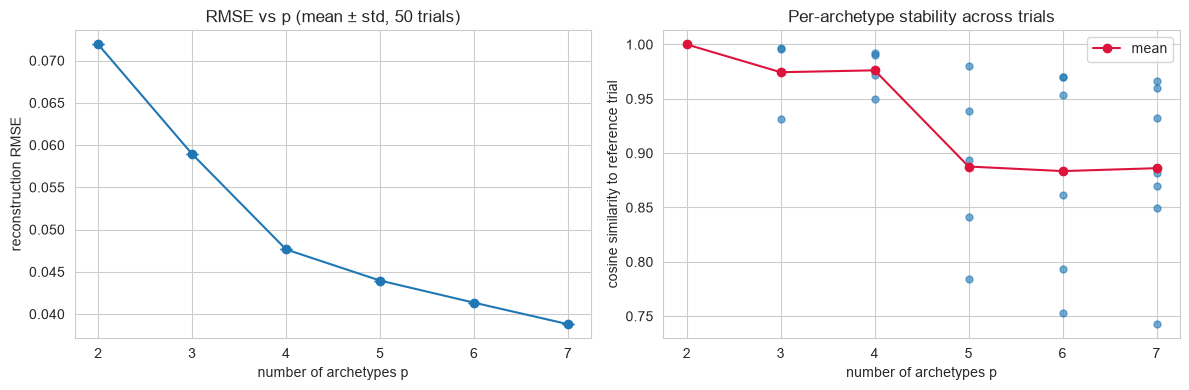

In [2]:
rmse_mean = [sweep[p]['meta']['rmse_mean'] for p in ps]
rmse_std  = [sweep[p]['meta']['rmse_std'] for p in ps]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].errorbar(ps, rmse_mean, yerr=rmse_std, marker='o', capsize=4)
axes[0].set_xlabel('number of archetypes p')
axes[0].set_ylabel('reconstruction RMSE')
axes[0].set_title(f'RMSE vs p (mean ± std, {n_trials} trials)')

for p in ps:
    s = sweep[p]['meta']['stability_per_archetype']
    axes[1].scatter([p] * len(s), s, alpha=0.6, color='C0', s=25)
stab_mean = [np.mean(sweep[p]['meta']['stability_per_archetype']) for p in ps]
axes[1].plot(ps, stab_mean, color='crimson', marker='o', label='mean')
axes[1].set_xlabel('number of archetypes p')
axes[1].set_ylabel('cosine similarity to reference trial')
axes[1].set_title('Per-archetype stability across trials')
axes[1].legend()
fig.tight_layout()

## Archetype lineage

Consecutive p are Hungarian-matched by cosine similarity
(`src.unmixing.matching.archetype_lineage`). Grey links: matched pairs
(width ∝ similarity); red dashed: the archetype that appears/splits when
p increases. Labels show each archetype's top-loading candidate.

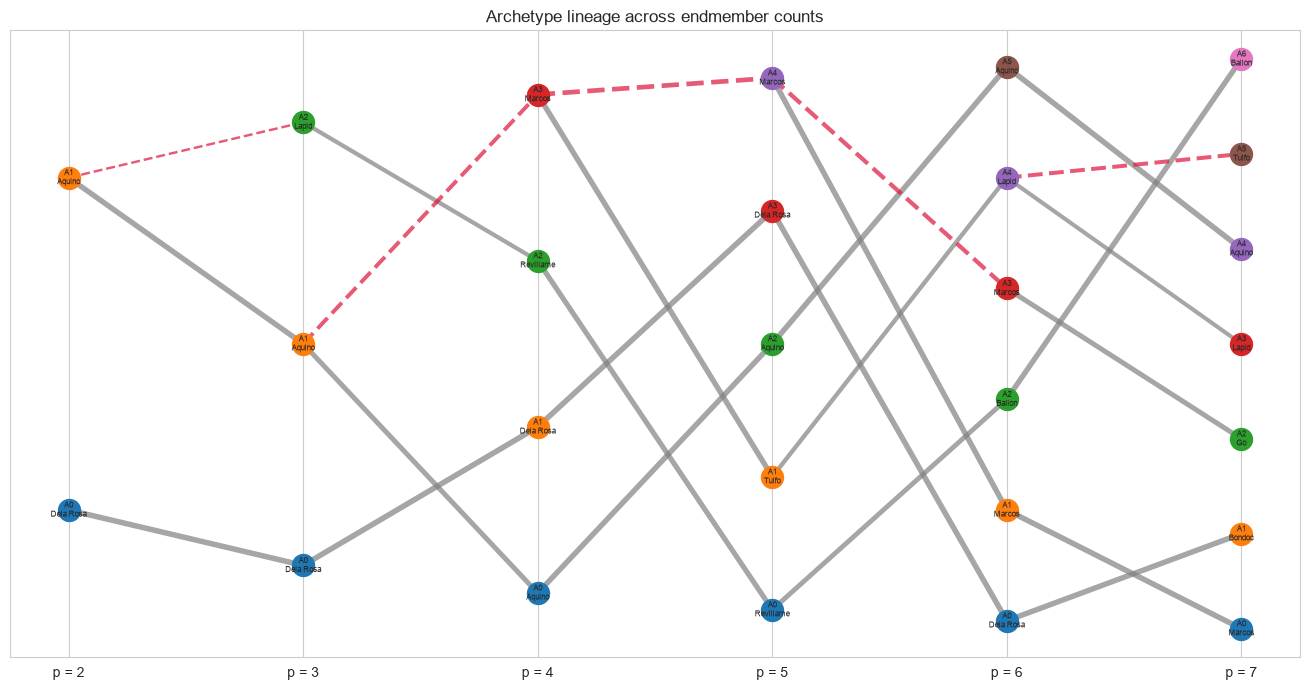

In [3]:
loadings_by_p = {p: sweep[p]['loadings_mean'].to_numpy() for p in ps}
edges = archetype_lineage(loadings_by_p)

def node_pos(p, k):
    return ps.index(p), (k + 0.5) / p

fig, ax = plt.subplots(figsize=(2.2 * len(ps), 7))
for e in edges:
    x0, y0 = node_pos(e['p_from'], e['k_from'])
    x1, y1 = node_pos(e['p_to'], e['k_to'])
    ax.plot([x0, x1], [y0, y1],
            color='crimson' if e['split'] else 'grey',
            ls='--' if e['split'] else '-',
            lw=1 + 3 * max(e['similarity'], 0), alpha=0.7, zorder=1)

for p in ps:
    lm = sweep[p]['loadings_mean']
    for k in range(p):
        x, y = node_pos(p, k)
        top = lm.iloc[:, k].idxmax().split(' [')[0].split(',')[0].title()
        ax.scatter([x], [y], s=250, color=f'C{k % 10}', zorder=2)
        ax.annotate(f'A{k}\n{top}', (x, y), ha='center', va='center',
                    fontsize=6, zorder=3)

ax.set_xticks(range(len(ps)))
ax.set_xticklabels([f'p = {p}' for p in ps])
ax.set_yticks([])
ax.set_title('Archetype lineage across endmember counts')
fig.tight_layout()

## Loadings with error bars at a chosen p

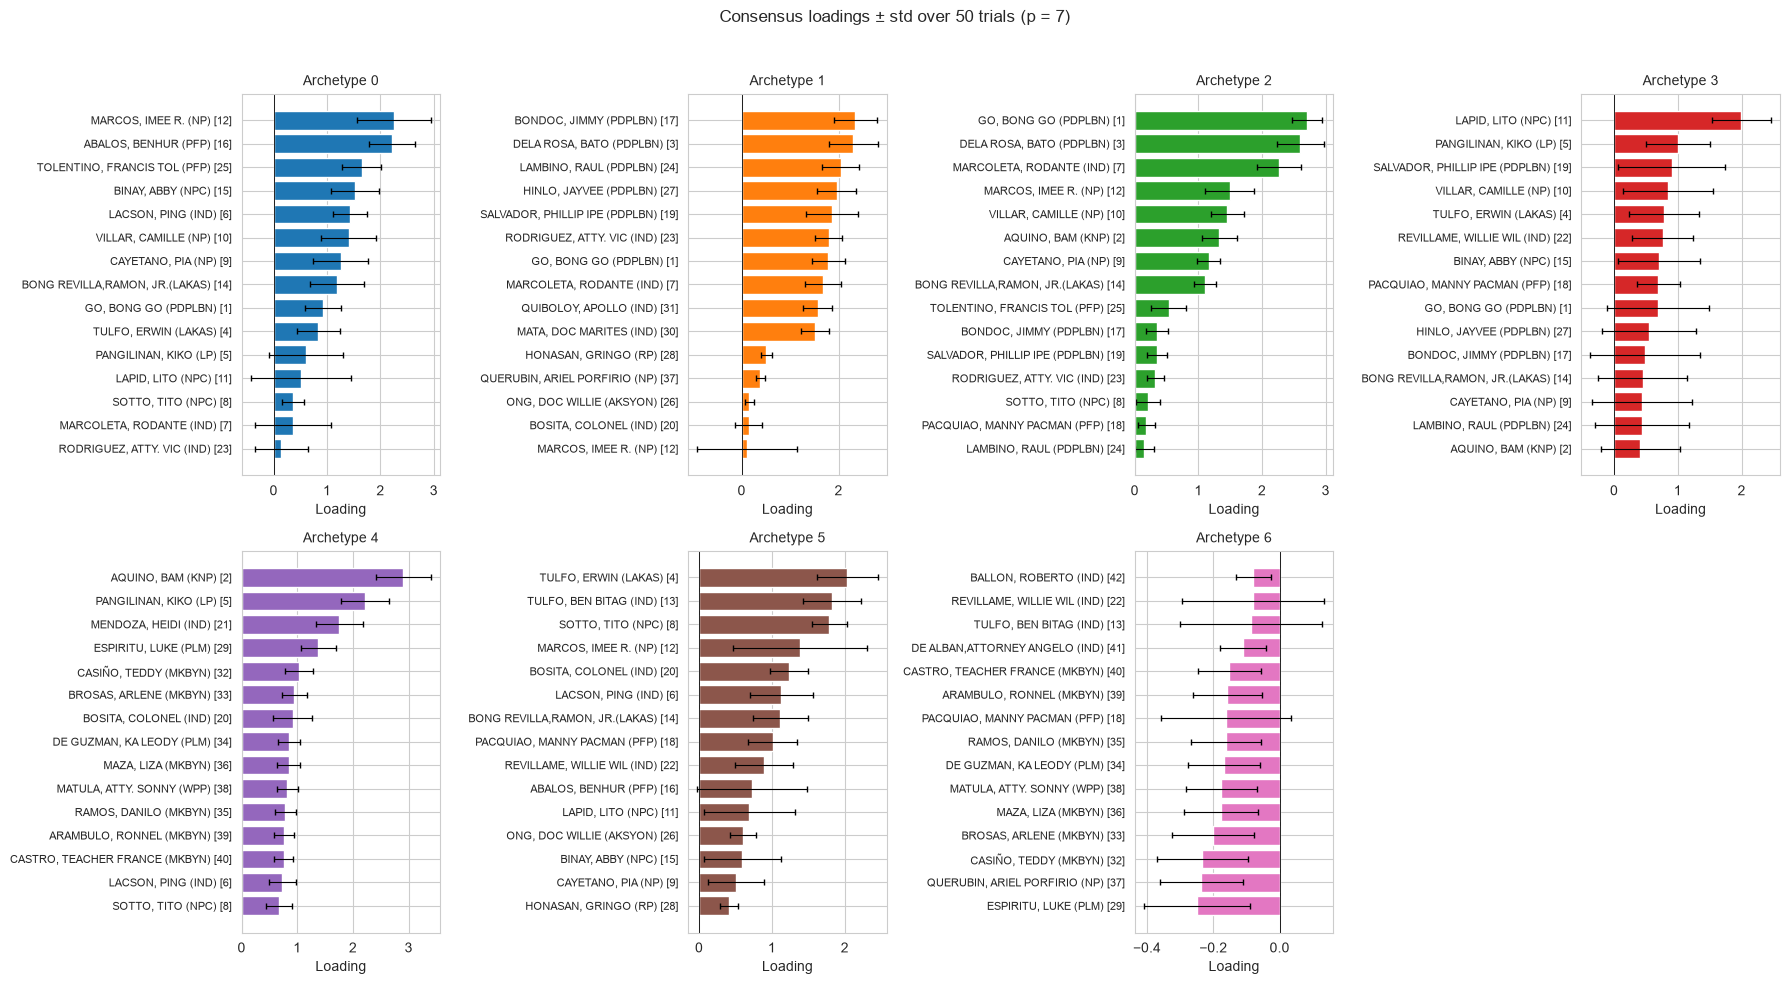

In [4]:
from src.figures import plot_archetypes_loadings_grid

p_show = ps[-1]
lm = sweep[p_show]['loadings_mean']
ls = sweep[p_show]['loadings_std']

plot_archetypes_loadings_grid(
    lm.to_numpy(), list(lm.index), stds=ls.to_numpy(), top_n=15,
    suptitle=f'Consensus loadings ± std over {n_trials} trials (p = {p_show})')

## Province map: mean and trial-to-trial std of an archetype

Municipality aggregates are re-aggregated per trial to province level
(ballot-weighted, exact), then mean/std are taken across trials — the std
map shows *where* the archetype's abundance estimate is uncertain.

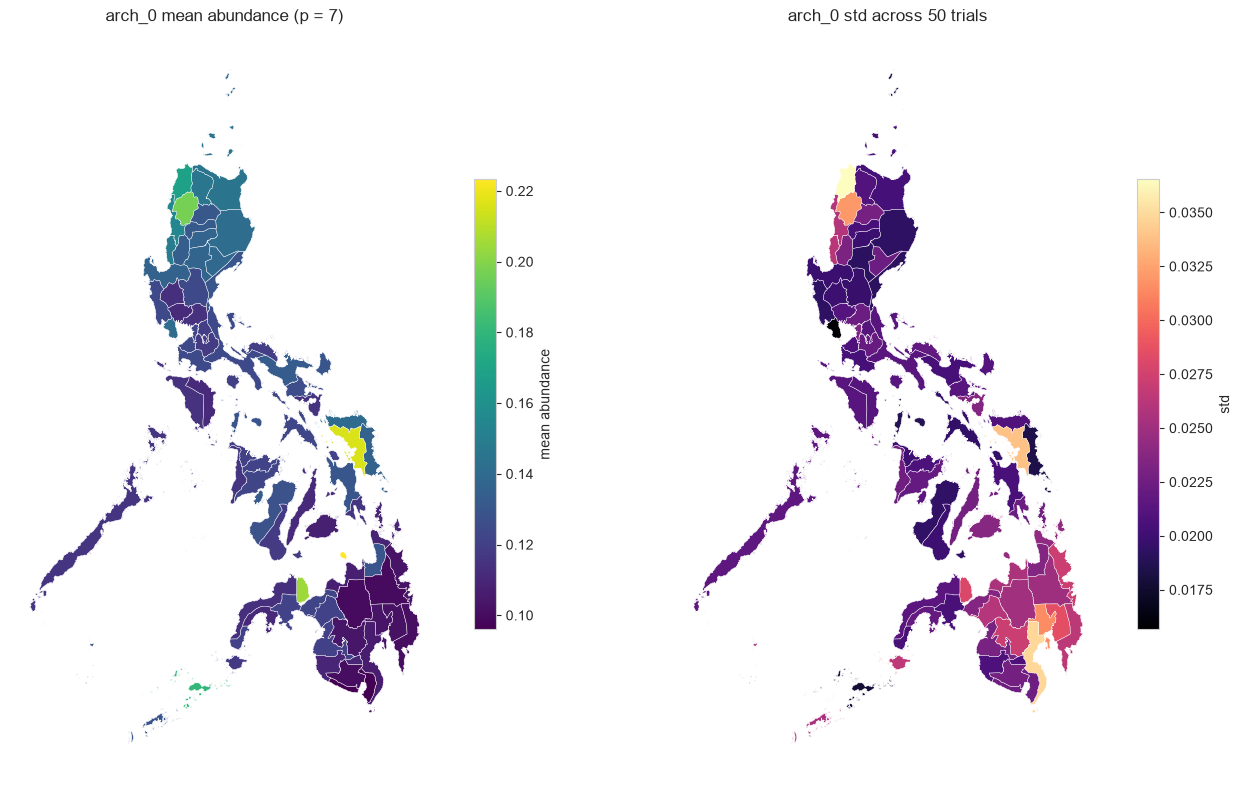

In [5]:
from src.geo import canonical_province, load_provinces
from src.figures import plot_choropleth

p_show, arch = ps[-1], 'arch_0'
df = sweep[p_show]['agg_trials'].copy()
wcol = 'information.numberOfValidBallot'
arch_cols = [c for c in df.columns if c.startswith('arch_')]

df['PROV_KEY'] = [canonical_province(pr, rg)
                  for pr, rg in zip(df['PROVINCE'], df['REGION'])]
for c in arch_cols:
    df[c + '_w'] = df[c] * df[wcol]
g = df.groupby(['trial', 'PROV_KEY'], observed=True).sum(numeric_only=True)
per_trial = pd.DataFrame({c: g[c + '_w'] / g[wcol] for c in arch_cols}).reset_index()

mean_prov = per_trial.groupby('PROV_KEY')[arch_cols].mean()
std_prov  = per_trial.groupby('PROV_KEY')[arch_cols].std(ddof=1)

provinces = load_provinces(config)
gdf = provinces.merge(mean_prov[[arch]].rename(columns={arch: 'mean'}), on='PROV_KEY') \
               .merge(std_prov[[arch]].rename(columns={arch: 'std'}), on='PROV_KEY')

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
plot_choropleth(gdf, 'mean', ax=axes[0],
                title=f'{arch} mean abundance (p = {p_show})',
                legend_label='mean abundance')
plot_choropleth(gdf, 'std', ax=axes[1], cmap='magma',
                title=f'{arch} std across {n_trials} trials',
                legend_label='std')
fig.tight_layout()